In [1]:
# Install only packages that are missing from this notebook kernel.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


# Paper figures and IEEE tables

This notebook rebuilds the main RQ1 and RQ2 figures from the saved evaluation CSV files. Edit the figure-size, marker, color, and axis settings in the configuration cell. Export commands are intentionally commented out.

## Configuration

These are the main controls to change when fitting a figure to one or two paper columns.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Find the repository whether the notebook starts from the repository root
# or from evaluation/notebooks.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "evaluation").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "evaluation").is_dir():
    raise FileNotFoundError("Run this notebook from inside the repository.")

EVALUATION = REPO_ROOT / "evaluation"
FIGURE_DIR = EVALUATION / "notebook-figures"
TABLE_DIR = EVALUATION / "notebook-tables"

# Change these values to reshape the figures.
WATERFALL_FIGSIZE = (9.5, 4.4)
COMPACT_RQ1_FIGSIZE = (7.2, 5.7)
PARETO_FIGSIZE = (7.2, 3.35)
PARETO_FOCUSED_YLIM = (0.78, 0.90)
PARETO_FULL_YLIM = (0.0, 1.0)
BAR_WIDTH = 0.22
MARKER_SIZE = 75
FRONTIER_MARKER_SIZE = 120
DPI = 300

INK = "#2F3B45"
SITE_LABELS = {
    "anvil": "Anvil",
    "stampede3": "Stampede3",
    "notre-dame-crc": "ND CRC",
}
SITE_ORDER = list(SITE_LABELS)
SITE_COLORS = {
    "Anvil": "#4472C4",
    "Stampede3": "#2A9D8F",
    "ND CRC": "#E07A5F",
}
OUTCOME_COLORS = {
    "correct_value": "#2A9D8F",
    "correct_abstention": "#4472C4",
    "incorrect_value": "#D1495B",
    "false_abstention": "#E69F00",
    "unsupported_value": "#8064A2",
}
METRIC_COLORS = {
    "Precision": "#4472C4",
    "Recall": "#2A9D8F",
    "Correct abstention": "#8064A2",
    "Field accuracy": "#E69F00",
}
ABSTENTION_COLORS = {
    "Correct abstention": "#2A9D8F",
    "False abstention": "#E69F00",
    "Unsupported fill": "#8064A2",
}
HEATMAP_COLORS = ["#F2F5F7", "#B7D5DA", "#5E9EAD", "#245B78"]
MODEL_LABELS = {
    "gpt-5-mini": "GPT-5 Mini",
    "gpt-5.6-terra": "GPT-5.6 Terra",
    "gemini-3.6-flash": "Gemini Flash",
    "gemini-3.1-pro-preview": "Gemini Pro",
}
MODEL_SHORT_LABELS = {
    "GPT-5 Mini": "Mini",
    "GPT-5.6 Terra": "Terra",
    "Gemini Flash": "Flash",
    "Gemini Pro": "Pro",
}
MODEL_COLORS = {
    "GPT-5 Mini": "#4472C4",
    "GPT-5.6 Terra": "#2A9D8F",
    "Gemini Flash": "#E07A5F",
    "Gemini Pro": "#8064A2",
}
MODE_LABELS = {
    "bm25": "BM25",
    "expanded": "LLM-expanded BM25",
    "full-corpus": "Full corpus",
}
# Edit these values to change retrieval marker shapes.
MODE_MARKERS = {
    "BM25": "o",
    "LLM-expanded BM25": "s",
    "Full corpus": "^",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "axes.edgecolor": "#BEC7CE",
    "grid.color": "#DDE2E6",
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
})

## Load saved evaluation tables

In [3]:
rq1_tables = EVALUATION / "rq1" / "tables"
rq2_tables = EVALUATION / "rq2" / "tables"

completion = pd.read_csv(rq1_tables / "profile-completion-waterfall.csv")
site_metrics = pd.read_csv(rq1_tables / "site-metrics.csv")
citation_summary = pd.read_csv(rq1_tables / "citation-summary.csv")
conflict_summary = pd.read_csv(rq1_tables / "conflict-category-summary.csv")
combined_outcomes = pd.read_csv(rq1_tables / "combined-outcome-counts.csv")
evidence_metrics = pd.read_csv(rq1_tables / "evidence-class-metrics.csv")
section_metrics = pd.read_csv(rq1_tables / "section-metrics.csv")
run_metrics = pd.read_csv(rq1_tables / "run-metrics.csv")
field_errors = pd.read_csv(rq1_tables / "field-error-frequency.csv")
measurement_recoveries = pd.read_csv(
    rq1_tables / "measurement-gap-recoveries.csv"
)
gpu_recovery = pd.read_csv(rq1_tables / "gpu-recovery-summary.csv")
matching_sensitivity = pd.read_csv(rq1_tables / "matching-sensitivity.csv")
model_retrieval = pd.read_csv(rq2_tables / "model-retrieval-summary.csv")
model_summary = pd.read_csv(rq2_tables / "model-summary.csv")
retrieval_summary = pd.read_csv(rq2_tables / "retrieval-summary.csv")
expanded_variance = pd.read_csv(rq2_tables / "expanded-variance.csv")

print(f"Loaded RQ1 and RQ2 tables from {EVALUATION}")
display(completion.head())

Loaded RQ1 and RQ2 tables from /Users/saiful/ai-projects/hpc-site-preflight/evaluation


,site,completion_segment,weighted_fields,weighted_total,ground_truth_fields,fraction,fields_per_profile
0,anvil,measured_correctly,660.000000,1764.0,147,0.374150,55.000000
1,anvil,recovered_documentation,385.000000,1764.0,147,0.218254,32.083333
2,anvil,recovered_pilot,151.666667,1764.0,147,0.085979,12.638889
3,anvil,correct_abstention,372.000000,1764.0,147,0.210884,31.000000
4,anvil,error_or_unresolved,195.333333,1764.0,147,0.110733,16.277778


## RQ1 profile-completion waterfall

Each floating bar adds one evidence path. The final bar is the cumulative correctly completed fraction; the gap to 100% is incorrect or unresolved.

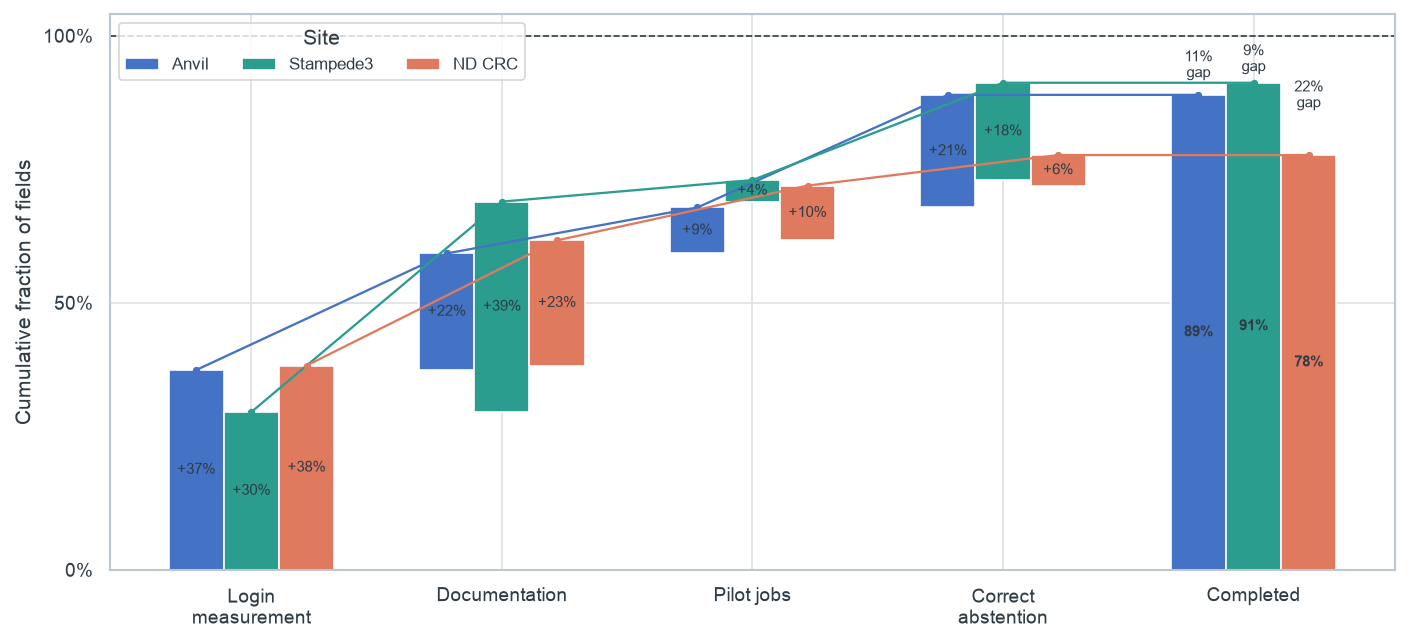

In [4]:
COMPLETION_ORDER = [
    "measured_correctly",
    "recovered_documentation",
    "recovered_pilot",
    "correct_abstention",
    "error_or_unresolved",
]
STAGE_LABELS = [
    "Login\nmeasurement",
    "Documentation",
    "Pilot jobs",
    "Correct\nabstention",
    "Completed",
]


def draw_completion_waterfall(
    axis,
    summary,
    *,
    bar_width=BAR_WIDTH,
    show_values=True,
    compact=False,
):
    """Draw the cumulative completion waterfall on an existing axis."""
    fractions = summary.pivot(
        index="site", columns="completion_segment", values="fraction"
    ).reindex(index=SITE_ORDER, columns=COMPLETION_ORDER, fill_value=0)
    contributions = COMPLETION_ORDER[:-1]
    x = np.arange(len(STAGE_LABELS), dtype=float)
    offsets = np.linspace(-bar_width, bar_width, len(fractions))

    for site_index, (site, values) in enumerate(fractions.iterrows()):
        increments = values[contributions].fillna(0).to_numpy(dtype=float)
        before = np.concatenate(([0.0], np.cumsum(increments)[:-1]))
        after = np.cumsum(increments)
        completed_fraction = after[-1]
        gap = float(values["error_or_unresolved"])
        label = SITE_LABELS[site]
        color = SITE_COLORS[label]

        for stage_index, (height, bottom) in enumerate(
            zip(increments, before, strict=True)
        ):
            axis.bar(
                x[stage_index] + offsets[site_index],
                height,
                width=bar_width,
                bottom=bottom,
                color=color,
                label=label if stage_index == 0 else None,
            )
            if show_values and height >= 0.035:
                axis.text(
                    x[stage_index] + offsets[site_index],
                    bottom + height / 2,
                    f"+{height:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

        axis.bar(
            x[-1] + offsets[site_index],
            completed_fraction,
            width=bar_width,
            color=color,
        )
        if show_values:
            axis.text(
                x[-1] + offsets[site_index],
                completed_fraction / 2,
                f"{completed_fraction:.0%}",
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold",
            )
            if gap >= 0.035:
                axis.text(
                    x[-1] + offsets[site_index],
                    completed_fraction + gap / 2,
                    f"{gap:.0%}\ngap",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

        axis.plot(
            x + offsets[site_index],
            [*after, completed_fraction],
            marker="o",
            linewidth=1.1,
            markersize=2.5,
            color=color,
        )

    axis.axhline(1, color=INK, linewidth=0.8, linestyle="--")
    axis.set_ylim(0, 1.04)
    axis.set_xticks(x, STAGE_LABELS)
    axis.set_ylabel("Cumulative fraction of fields")
    axis.set_yticks([0, 0.5, 1], ["0%", "50%", "100%"])
    axis.legend(
        title=None if compact else "Site",
        ncol=3,
        loc="upper left",
        fontsize=6 if compact else 8,
    )
    return axis


figure, axis = plt.subplots(figsize=WATERFALL_FIGSIZE)
draw_completion_waterfall(axis, completion)
figure.tight_layout()
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# figure.savefig(FIGURE_DIR / "profile-completion-waterfall.png", dpi=DPI, bbox_inches="tight")
# figure.savefig(FIGURE_DIR / "profile-completion-waterfall.pdf", bbox_inches="tight")

## Compact RQ1 summary

Panel (a) uses the same waterfall without internal labels. The remaining panels show abstention behavior, citation integrity, and evidence conflicts.

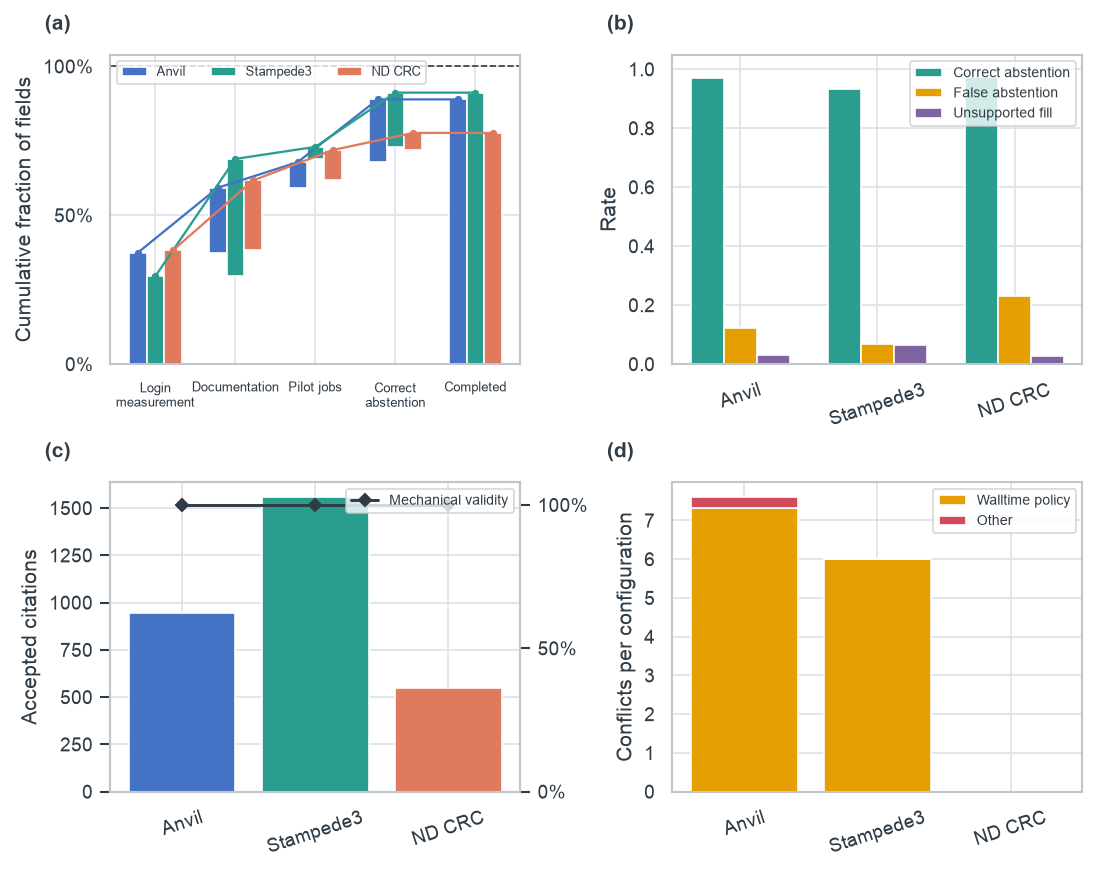

In [5]:
def plot_compact_rq1(
    completion_table,
    metrics_table,
    citations_table,
    conflicts_table,
    *,
    figsize=COMPACT_RQ1_FIGSIZE,
):
    """Build the four-panel compact RQ1 figure."""
    figure, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

    draw_completion_waterfall(
        axes[0, 0], completion_table, show_values=False, compact=True
    )
    axes[0, 0].tick_params(axis="x", labelsize=6)

    abstention_colors = {
        "Correct abstention": "#2A9D8F",
        "False abstention": "#E69F00",
        "Unsupported fill": "#8064A2",
    }
    abstention_columns = [
        "abstention_accuracy",
        "false_abstention_rate",
        "unsupported_fill_rate",
    ]
    abstention_labels = list(abstention_colors)
    x = np.arange(len(metrics_table))
    width = 0.24
    for offset, column, label in zip(
        (-width, 0, width), abstention_columns, abstention_labels, strict=True
    ):
        axes[0, 1].bar(
            x + offset,
            metrics_table[column],
            width,
            label=label,
            color=abstention_colors[label],
        )
    axes[0, 1].set_xticks(
        x, [SITE_LABELS[site] for site in metrics_table["site"]], rotation=18
    )
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].set_ylabel("Rate")
    axes[0, 1].legend(fontsize=6.5, loc="upper right")

    citation_labels = [SITE_LABELS[site] for site in citations_table["site"]]
    citation_colors = [SITE_COLORS[label] for label in citation_labels]
    axes[1, 0].bar(
        citation_labels, citations_table["citations"], color=citation_colors
    )
    axes[1, 0].set_ylabel("Accepted citations")
    axes[1, 0].tick_params(axis="x", labelrotation=18)
    validity_axis = axes[1, 0].twinx()
    validity_axis.plot(
        citation_labels,
        citations_table["mechanical_citation_validity"],
        color=INK,
        marker="D",
        linewidth=1.4,
        markersize=4,
        label="Mechanical validity",
    )
    validity_axis.set_ylim(0, 1.08)
    validity_axis.set_yticks([0, 0.5, 1], ["0%", "50%", "100%"])
    validity_axis.grid(False)
    validity_axis.legend(fontsize=6.5, loc="upper right")

    conflict_frame = conflicts_table.pivot(
        index="site",
        columns="conflict_category",
        values="conflicts_per_configuration",
    ).fillna(0).reindex(SITE_ORDER, fill_value=0)
    for column in ("walltime_policy", "other"):
        if column not in conflict_frame:
            conflict_frame[column] = 0
    conflict_labels = [SITE_LABELS[site] for site in conflict_frame.index]
    axes[1, 1].bar(
        conflict_labels,
        conflict_frame["walltime_policy"],
        label="Walltime policy",
        color="#E69F00",
    )
    axes[1, 1].bar(
        conflict_labels,
        conflict_frame["other"],
        bottom=conflict_frame["walltime_policy"],
        label="Other",
        color="#D1495B",
    )
    axes[1, 1].set_ylabel("Conflicts per configuration")
    axes[1, 1].tick_params(axis="x", labelrotation=18)
    axes[1, 1].legend(fontsize=6.5, loc="upper right")

    for label, panel in zip(("a", "b", "c", "d"), axes.flat, strict=True):
        panel.text(
            -0.16,
            1.08,
            f"({label})",
            transform=panel.transAxes,
            fontsize=10,
            fontweight="bold",
        )
    return figure, axes


compact_figure, compact_axes = plot_compact_rq1(
    completion, site_metrics, citation_summary, conflict_summary
)
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# compact_figure.savefig(FIGURE_DIR / "rq1-compact-summary.png", dpi=DPI, bbox_inches="tight")
# compact_figure.savefig(FIGURE_DIR / "rq1-compact-summary.pdf", bbox_inches="tight")

## RQ1 site-level metrics

**How to read it.** Precision measures how often populated values are correct; recall measures how many expected values are recovered. Abstention accuracy measures whether absent values remain absent, and field accuracy counts both correct values and correct abstentions.

**Current observation.** Stampede3 has the highest field accuracy (0.912), followed by Anvil (0.889) and ND CRC (0.777). Precision remains high at every site, while recall falls at the less-completely described ND CRC site.

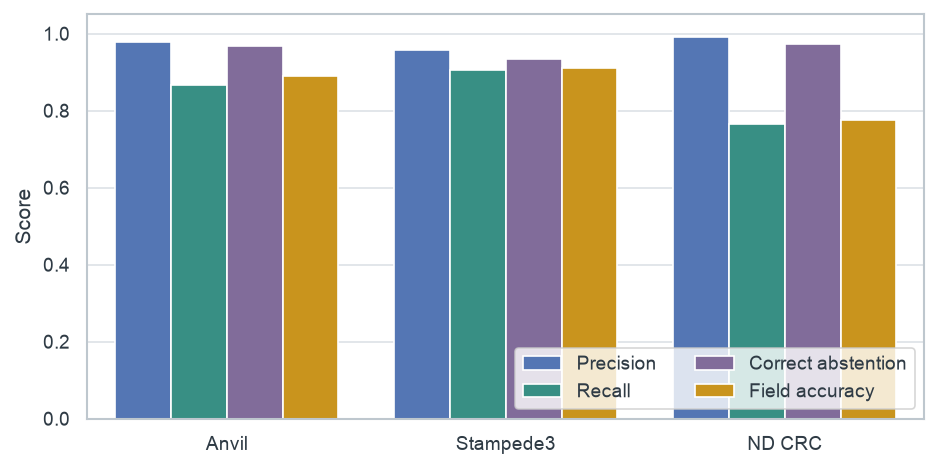

In [6]:
metric_columns = ["precision", "recall", "abstention_accuracy", "field_accuracy"]
metric_frame = site_metrics.melt(
    id_vars="site", value_vars=metric_columns,
    var_name="metric", value_name="value",
)
metric_frame["site"] = metric_frame["site"].map(SITE_LABELS)
metric_frame["metric"] = metric_frame["metric"].map({
    "precision": "Precision",
    "recall": "Recall",
    "abstention_accuracy": "Correct abstention",
    "field_accuracy": "Field accuracy",
})
site_metric_figure, site_metric_axis = plt.subplots(figsize=(7.2, 3.5))
sns.barplot(
    data=metric_frame, x="site", y="value", hue="metric",
    palette=METRIC_COLORS, ax=site_metric_axis,
)
site_metric_axis.set(xlabel="", ylabel="Score", ylim=(0, 1.05))
site_metric_axis.legend(title="", ncol=2, loc="lower right")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# site_metric_figure.savefig(FIGURE_DIR / "site-metrics.png", dpi=DPI, bbox_inches="tight")
# site_metric_figure.savefig(FIGURE_DIR / "site-metrics.pdf", bbox_inches="tight")

## RQ1 field-outcome counts

**How to read it.** The left panel separates correct populated values from correctly detected absence. The right panel separates wrong populated values from values that should have been populated but remained unresolved.

**Current observation.** Correct outcomes greatly outnumber errors. Most residual errors are missed values rather than confident wrong fills, which is consistent with the pipeline's conservative extraction rule.

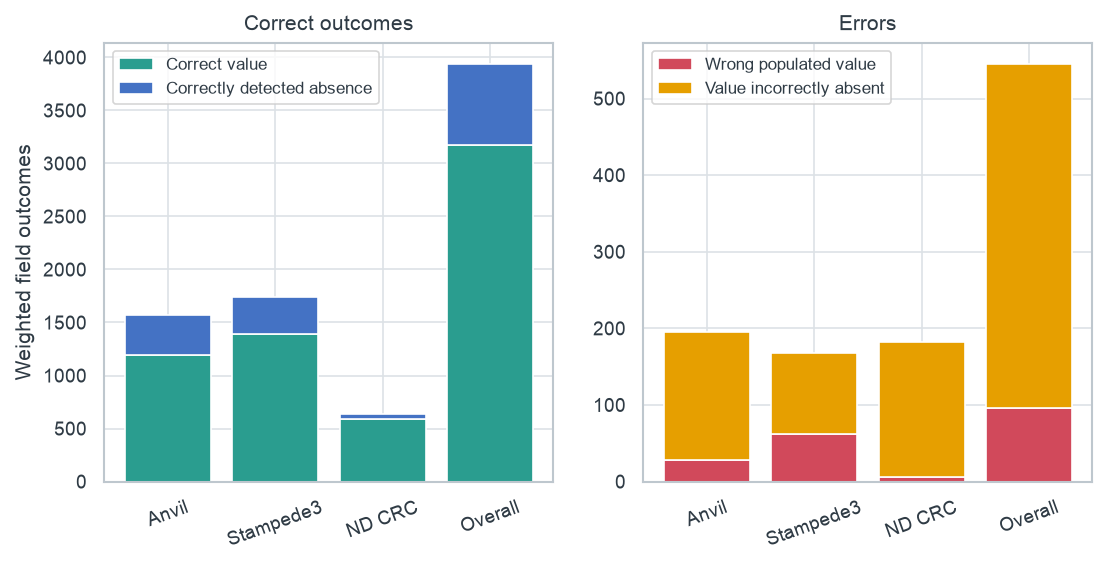

In [7]:
outcome_labels = {
    "correct_value": "Correct value",
    "correct_absence": "Correctly detected absence",
    "wrong_populated_value": "Wrong populated value",
    "missed_value": "Value incorrectly absent",
}
outcome_colors = [
    OUTCOME_COLORS["correct_value"],
    OUTCOME_COLORS["correct_abstention"],
    OUTCOME_COLORS["incorrect_value"],
    OUTCOME_COLORS["false_abstention"],
]
outcome_columns = list(outcome_labels)
outcome_sites = [
    "Overall" if site == "overall" else SITE_LABELS[site]
    for site in combined_outcomes["site"]
]
outcome_figure, outcome_axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
for axis, columns, colors, title in [
    (outcome_axes[0], outcome_columns[:2], outcome_colors[:2], "Correct outcomes"),
    (outcome_axes[1], outcome_columns[2:], outcome_colors[2:], "Errors"),
]:
    bottom = np.zeros(len(combined_outcomes))
    for column, color in zip(columns, colors, strict=True):
        values = combined_outcomes[column].to_numpy()
        axis.bar(
            outcome_sites, values, bottom=bottom,
            label=outcome_labels[column], color=color,
        )
        bottom += values
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=20)
    axis.legend(fontsize=8)
outcome_axes[0].set_ylabel("Weighted field outcomes")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# outcome_figure.savefig(FIGURE_DIR / "combined-outcome-counts.png", dpi=DPI, bbox_inches="tight")
# outcome_figure.savefig(FIGURE_DIR / "combined-outcome-counts.pdf", bbox_inches="tight")

## RQ1 accuracy by evidence class

**How to read it.** Identity and configuration mainly originate in login measurements, policy mainly originates in documentation, and capability mainly originates in pilot jobs.

**Current observation.** Identity is perfect in this matrix and configuration is consistently strong. Policy accuracy is lower because it depends on discovery and extraction. ND CRC capability is lowest (0.583), exposing unresolved pilot-dependent fields.

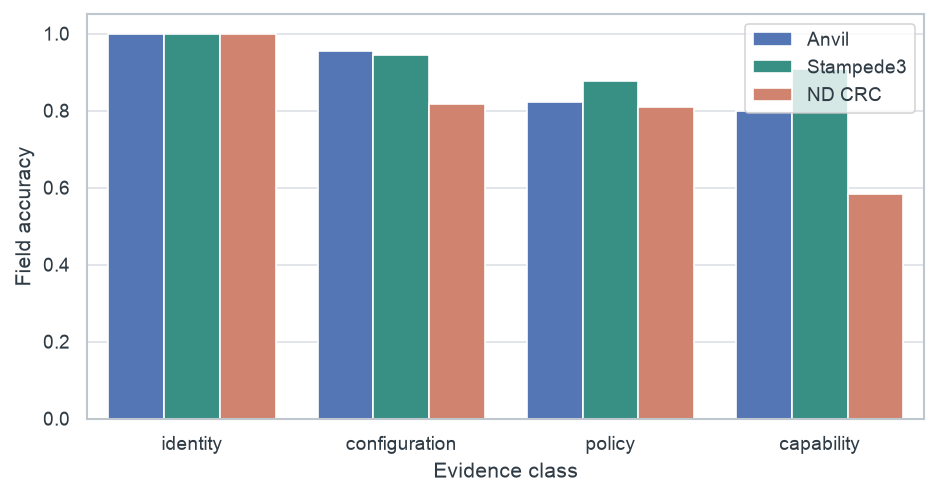

In [8]:
evidence_frame = evidence_metrics.copy()
evidence_frame["site"] = evidence_frame["site"].map(SITE_LABELS)
evidence_figure, evidence_axis = plt.subplots(figsize=(7.2, 3.5))
sns.barplot(
    data=evidence_frame,
    x="evidence_class", y="field_accuracy", hue="site",
    palette=SITE_COLORS,
    order=["identity", "configuration", "policy", "capability"],
    ax=evidence_axis,
)
evidence_axis.set(xlabel="Evidence class", ylabel="Field accuracy", ylim=(0, 1.05))
evidence_axis.legend(title="")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# evidence_figure.savefig(FIGURE_DIR / "accuracy-by-evidence-class.png", dpi=DPI, bbox_inches="tight")
# evidence_figure.savefig(FIGURE_DIR / "accuracy-by-evidence-class.pdf", bbox_inches="tight")

## RQ1 accuracy by profile section

**How to read it.** Each heatmap cell is balanced field accuracy for one site and profile section. Blank cells indicate that the section is not represented for that scheduler or site.

**Current observation.** The heatmap localizes errors hidden by aggregate metrics. Scheduler-specific and network sections are more variable than identity, while HTCondor and Slurm naturally occupy different columns.

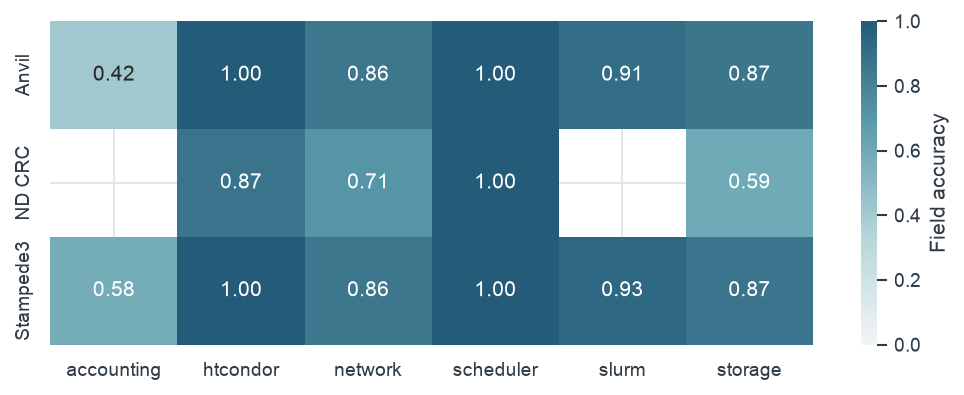

In [9]:
section_pivot = section_metrics.pivot(
    index="site", columns="section", values="field_accuracy"
).rename(index=SITE_LABELS)
section_figure, section_axis = plt.subplots(figsize=(8.2, 2.8))
sns.heatmap(
    section_pivot, annot=True, fmt=".2f", vmin=0, vmax=1,
    cmap=sns.blend_palette(HEATMAP_COLORS, as_cmap=True),
    cbar_kws={"label": "Field accuracy"}, ax=section_axis,
)
section_axis.set(xlabel="", ylabel="")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# section_figure.savefig(FIGURE_DIR / "accuracy-by-section.png", dpi=DPI, bbox_inches="tight")
# section_figure.savefig(FIGURE_DIR / "accuracy-by-section.pdf", bbox_inches="tight")

## RQ1 run-to-run accuracy distribution

**How to read it.** Each point is one completed profile build; the box summarizes the distribution at a site across models, retrieval strategies, and expanded-mode repetitions.

**Current observation.** Stampede3 results cluster tightly near the highest accuracy. Anvil is moderately variable. ND CRC has the lowest center and a wider lower tail, showing that site knowability matters.

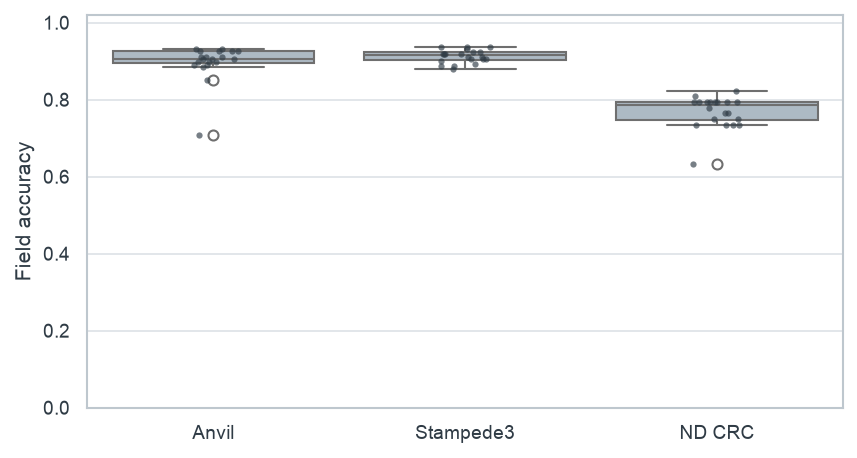

In [10]:
run_frame = run_metrics.copy()
run_frame["site"] = run_frame["site"].map(SITE_LABELS)
distribution_figure, distribution_axis = plt.subplots(figsize=(6.5, 3.4))
sns.boxplot(
    data=run_frame, x="site", y="field_accuracy",
    color="#A9BBC8", ax=distribution_axis,
)
sns.stripplot(
    data=run_frame, x="site", y="field_accuracy",
    color=INK, alpha=0.65, size=3, ax=distribution_axis,
)
distribution_axis.set(xlabel="", ylabel="Field accuracy", ylim=(0, 1.02))
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# distribution_figure.savefig(FIGURE_DIR / "run-accuracy-distribution.png", dpi=DPI, bbox_inches="tight")
# distribution_figure.savefig(FIGURE_DIR / "run-accuracy-distribution.pdf", bbox_inches="tight")

## RQ1 most frequent field errors

**How to read it.** Fields are ranked by the fraction of balanced configurations in which the final value is wrong, unsupported, or incorrectly absent.

**Current observation.** Errors concentrate in a small set of difficult fields rather than being evenly distributed. These rows are the most direct work list for improving schemas, retrieval queries, and validators.

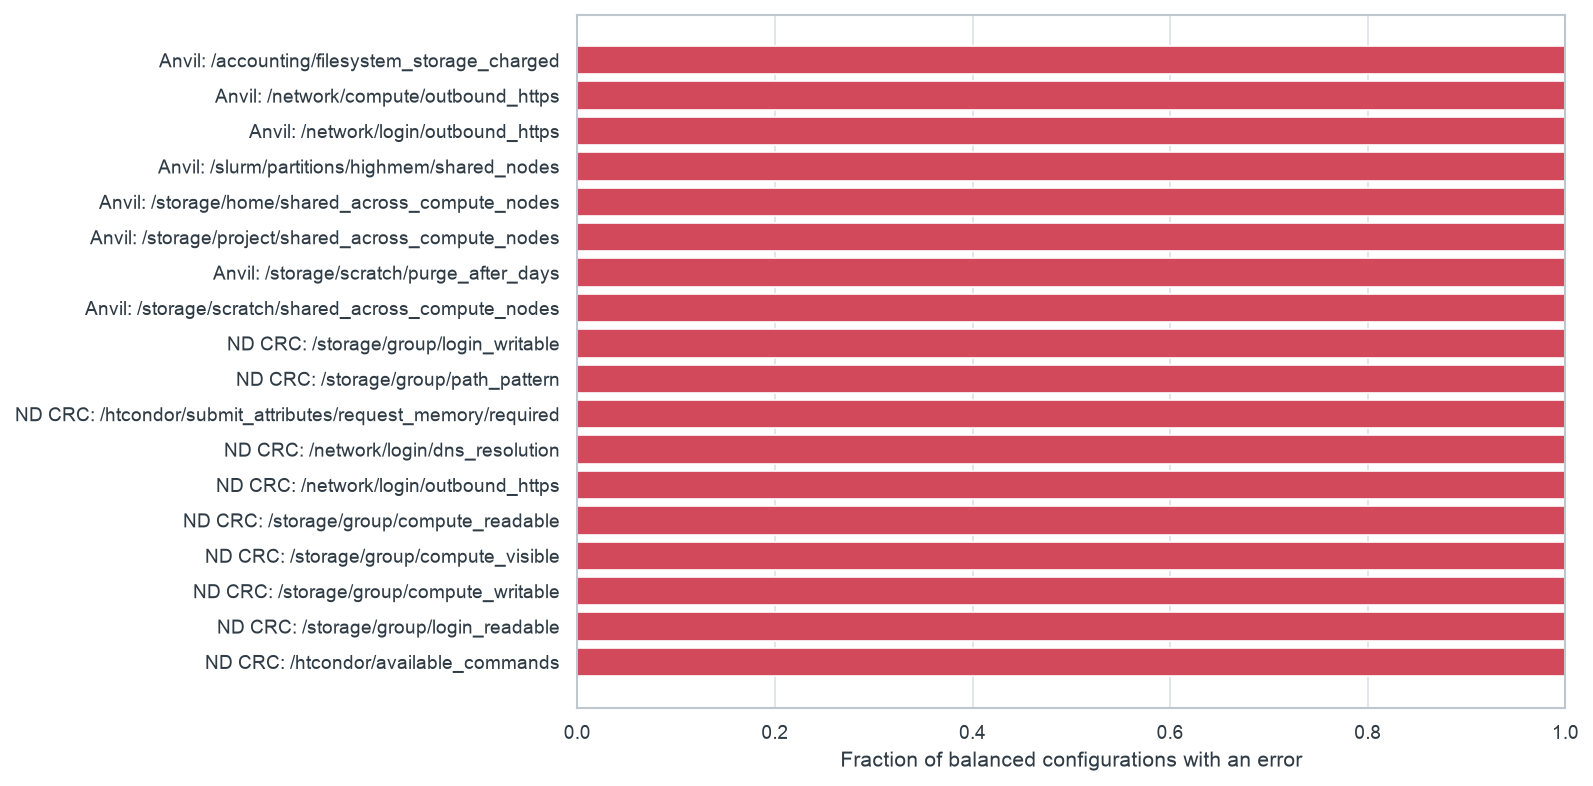

In [11]:
top_errors = field_errors.sort_values(
    ["error_rate", "weighted_errors"], ascending=False
).head(18).sort_values("error_rate")
error_labels = [
    f"{SITE_LABELS[site]}: {path}"
    for site, path in zip(top_errors["site"], top_errors["field_path"], strict=True)
]
error_figure, error_axis = plt.subplots(figsize=(8.5, 6.0))
error_axis.barh(
    error_labels, top_errors["error_rate"],
    color=OUTCOME_COLORS["incorrect_value"],
)
error_axis.set(xlabel="Fraction of balanced configurations with an error", xlim=(0, 1))
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# error_figure.savefig(FIGURE_DIR / "most-frequent-field-errors.png", dpi=DPI, bbox_inches="tight")
# error_figure.savefig(FIGURE_DIR / "most-frequent-field-errors.pdf", bbox_inches="tight")

## RQ1 abstention behavior

**How to read it.** Correct abstention is desirable when the reviewed reference marks a field absent. False abstention means a known value was missed; unsupported fill means the pipeline populated a field that should remain absent.

**Current observation.** Correct abstention exceeds 0.93 at every site. ND CRC has the largest false-abstention rate, while unsupported fills remain small, supporting the claim that the system usually fails conservatively.

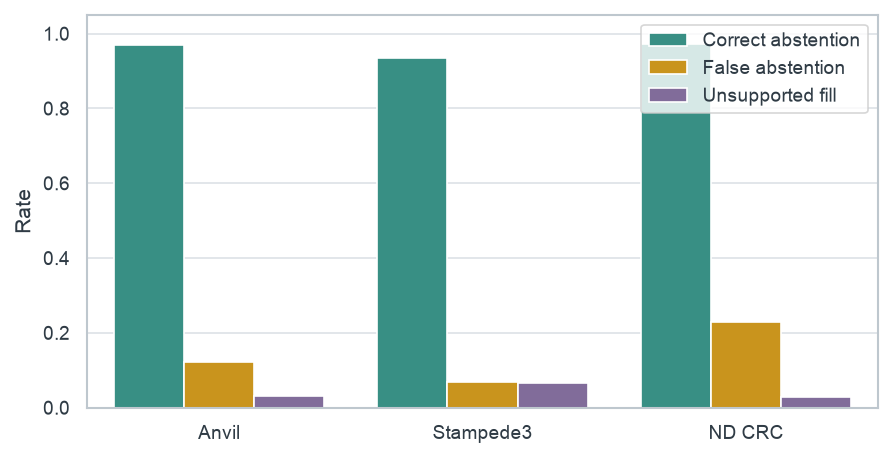

In [12]:
abstention_columns = [
    "abstention_accuracy", "false_abstention_rate", "unsupported_fill_rate"
]
abstention_frame = site_metrics.melt(
    id_vars="site", value_vars=abstention_columns,
    var_name="metric", value_name="value",
)
abstention_frame["site"] = abstention_frame["site"].map(SITE_LABELS)
abstention_frame["metric"] = abstention_frame["metric"].map({
    "abstention_accuracy": "Correct abstention",
    "false_abstention_rate": "False abstention",
    "unsupported_fill_rate": "Unsupported fill",
})
abstention_figure, abstention_axis = plt.subplots(figsize=(6.8, 3.4))
sns.barplot(
    data=abstention_frame, x="site", y="value", hue="metric",
    palette=ABSTENTION_COLORS, ax=abstention_axis,
)
abstention_axis.set(xlabel="", ylabel="Rate", ylim=(0, 1.05))
abstention_axis.legend(title="")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# abstention_figure.savefig(FIGURE_DIR / "abstention-behavior.png", dpi=DPI, bbox_inches="tight")
# abstention_figure.savefig(FIGURE_DIR / "abstention-behavior.pdf", bbox_inches="tight")

## RQ1 citation integrity

**How to read it.** Mechanical validity requires a citation to reference a stored, target-site corpus chunk. Citation count measures the volume of accepted documentary support, not semantic correctness by itself.

**Current observation.** Mechanical citation validity is 100% at all three sites. Stampede3 has the largest accepted citation volume because its documentation establishes more profile fields.

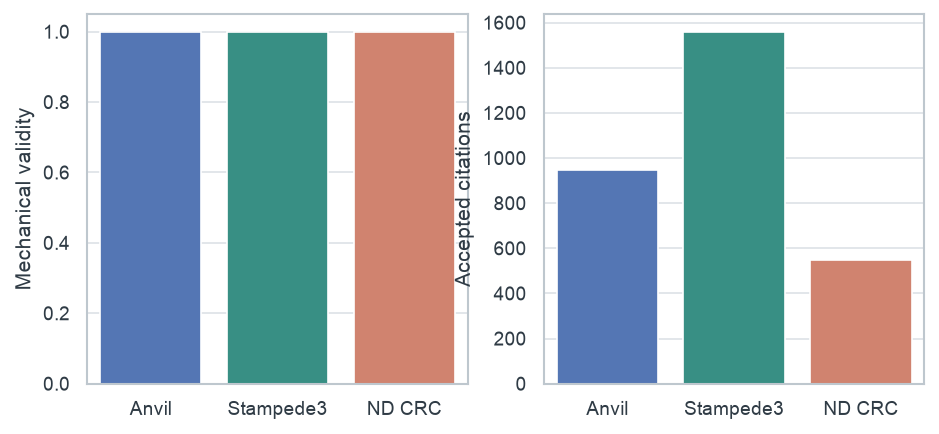

In [13]:
citation_frame = citation_summary.copy()
citation_frame["site"] = citation_frame["site"].map(SITE_LABELS)
citation_figure, citation_axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
sns.barplot(
    data=citation_frame, x="site", y="mechanical_citation_validity",
    hue="site", palette=SITE_COLORS, legend=False, ax=citation_axes[0],
)
citation_axes[0].set(xlabel="", ylabel="Mechanical validity", ylim=(0, 1.05))
sns.barplot(
    data=citation_frame, x="site", y="citations",
    hue="site", palette=SITE_COLORS, legend=False, ax=citation_axes[1],
)
citation_axes[1].set(xlabel="", ylabel="Accepted citations")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# citation_figure.savefig(FIGURE_DIR / "citation-integrity.png", dpi=DPI, bbox_inches="tight")
# citation_figure.savefig(FIGURE_DIR / "citation-integrity.pdf", bbox_inches="tight")

## RQ1 source conflicts

**How to read it.** These are explicit disagreements retained by reconciliation, reported per balanced configuration. Walltime-policy conflicts are separated from other conflicts.

**Current observation.** Anvil and Stampede3 repeatedly expose scheduler-versus-documentation walltime disagreement. ND CRC has no Slurm partition-walltime conflict because its evaluated scheduler is HTCondor.

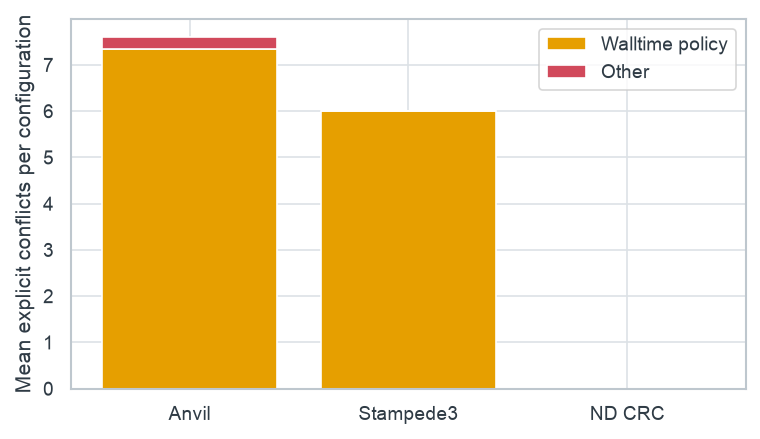

In [14]:
conflict_pivot = conflict_summary.pivot(
    index="site", columns="conflict_category",
    values="conflicts_per_configuration",
).fillna(0).reindex(SITE_ORDER, fill_value=0)
for column in ("walltime_policy", "other"):
    if column not in conflict_pivot:
        conflict_pivot[column] = 0
conflict_sites = [SITE_LABELS[site] for site in conflict_pivot.index]
conflict_figure, conflict_axis = plt.subplots(figsize=(5.8, 3.2))
conflict_axis.bar(
    conflict_sites, conflict_pivot["walltime_policy"],
    label="Walltime policy", color=OUTCOME_COLORS["false_abstention"],
)
conflict_axis.bar(
    conflict_sites, conflict_pivot["other"],
    bottom=conflict_pivot["walltime_policy"],
    label="Other", color=OUTCOME_COLORS["incorrect_value"],
)
conflict_axis.set_ylabel("Mean explicit conflicts per configuration")
conflict_axis.legend()
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# conflict_figure.savefig(FIGURE_DIR / "source-conflicts.png", dpi=DPI, bbox_inches="tight")
# conflict_figure.savefig(FIGURE_DIR / "source-conflicts.pdf", bbox_inches="tight")

## RQ1 measurement-gap recovery

**How to read it.** A recovery is a correct final value for which login measurement supplied no usable value. The count is normalized per balanced configuration.

**Current observation.** Later documentation and pilot evidence recover substantial information at every site. This demonstrates why measurement-only profiles are incomplete even when their measured fields are reliable.

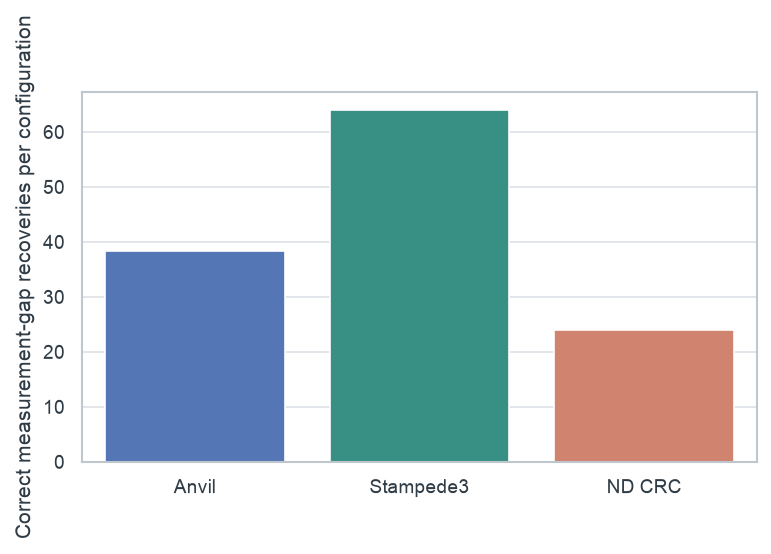

In [15]:
gap_weighted = measurement_recoveries.groupby(
    "site", as_index=False
)["analysis_weight"].sum().rename(columns={"analysis_weight": "weighted_recoveries"})
gap_weighted["recoveries_per_configuration"] = gap_weighted["weighted_recoveries"] / 12
gap_weighted = pd.DataFrame({"site": SITE_ORDER}).merge(
    gap_weighted, on="site", how="left"
).fillna(0)
gap_weighted["site"] = gap_weighted["site"].map(SITE_LABELS)
gap_figure, gap_axis = plt.subplots(figsize=(5.8, 3.2))
sns.barplot(
    data=gap_weighted, x="site", y="recoveries_per_configuration",
    hue="site", palette=SITE_COLORS, legend=False, ax=gap_axis,
)
gap_axis.set(xlabel="", ylabel="Correct measurement-gap recoveries per configuration")
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# gap_figure.savefig(FIGURE_DIR / "measurement-gap-recovery.png", dpi=DPI, bbox_inches="tight")
# gap_figure.savefig(FIGURE_DIR / "measurement-gap-recovery.pdf", bbox_inches="tight")

## RQ1 GPU measurement-gap recovery

**How to read it.** Each row is a GPU fact that the login measurement did not establish. The recovery rate is the fraction of balanced configurations that reconstructed the reviewed value from documentation.

**Current observation.** Stampede3 GPU counts and models are recovered consistently, while Anvil GPU-model recovery is model-dependent and much lower. This is the clearest field-level example of model divergence hidden by aggregate accuracy.

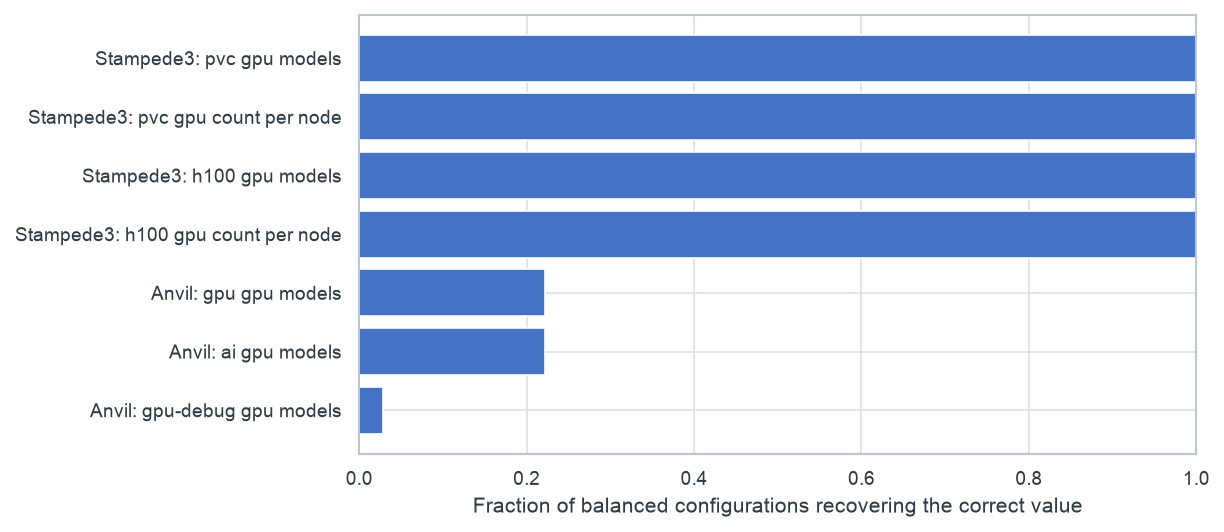

In [16]:
gpu_frame = gpu_recovery.copy()
gpu_frame["label"] = gpu_frame.apply(
    lambda row: (
        f"{SITE_LABELS[row['site']]}: "
        f"{row['field_path'].split('/')[3]} "
        f"{row['field_path'].split('/')[-1].replace('_', ' ')}"
    ),
    axis=1,
)
gpu_frame = gpu_frame.sort_values("recovery_rate")
gpu_figure, gpu_axis = plt.subplots(figsize=(7.2, 3.8))
gpu_axis.barh(gpu_frame["label"], gpu_frame["recovery_rate"], color="#4472C4")
gpu_axis.set(
    xlabel="Fraction of balanced configurations recovering the correct value",
    xlim=(0, 1),
)
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# gpu_figure.savefig(FIGURE_DIR / "gpu-measurement-gap-recovery.png", dpi=DPI, bbox_inches="tight")
# gpu_figure.savefig(FIGURE_DIR / "gpu-measurement-gap-recovery.pdf", bbox_inches="tight")

## RQ2 quality-cost Pareto plots

**How to read it.** All data markers have the same size. Color represents model, shape represents retrieval strategy, and the dashed line marks configurations for which no other point is both cheaper and at least as accurate. Panel (a) uses extraction tokens as cost; panel (b) uses latency.

**Current observation.** Full corpus is dominated: it roughly doubles token use and latency without improving aggregate accuracy. Gemini Flash reaches the highest field accuracy, while GPT-5.6 Terra lies close to it with substantially lower cost and latency. The focused field-accuracy axis is truncated to expose differences among configurations.

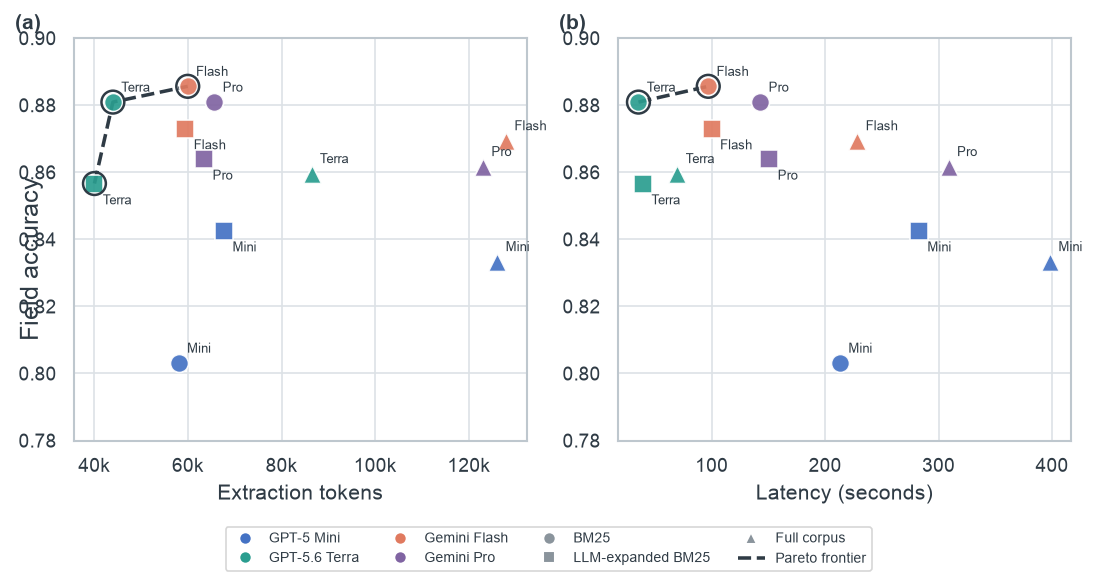

In [17]:
def pareto_frontier(frame, cost_column):
    """Return points not dominated on lower cost and higher accuracy."""
    ordered = frame.sort_values(
        [cost_column, "field_accuracy"], ascending=[True, False]
    )
    best_accuracy = -np.inf
    rows = []
    for _, row in ordered.iterrows():
        if row["field_accuracy"] > best_accuracy:
            rows.append(row)
            best_accuracy = row["field_accuracy"]
    return pd.DataFrame(rows)


def plot_quality_cost_pareto(
    interaction_table,
    *,
    figsize=PARETO_FIGSIZE,
    ylim=PARETO_FOCUSED_YLIM,
    marker_size=MARKER_SIZE,
    frontier_marker_size=FRONTIER_MARKER_SIZE,
    annotate=True,
):
    """Plot accuracy against extraction tokens and latency."""
    frame = interaction_table.copy()
    frame["model"] = frame["model"].map(MODEL_LABELS)
    frame["mode"] = frame["mode"].map(MODE_LABELS)
    figure, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    panels = [
        ("a", "extraction_tokens", "Extraction tokens", axes[0]),
        ("b", "latency_sec", "Latency (seconds)", axes[1]),
    ]
    for panel_label, cost_column, xlabel, axis in panels:
        for _, row in frame.iterrows():
            axis.scatter(
                row[cost_column],
                row["field_accuracy"],
                s=marker_size,
                color=MODEL_COLORS[row["model"]],
                marker=MODE_MARKERS[row["mode"]],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.92,
                zorder=3,
            )
            if annotate:
                offset = -10 if row["mode"] == "LLM-expanded BM25" else 5
                axis.annotate(
                    MODEL_SHORT_LABELS[row["model"]],
                    (row[cost_column], row["field_accuracy"]),
                    xytext=(4, offset),
                    textcoords="offset points",
                    fontsize=6,
                )

        frontier = pareto_frontier(frame, cost_column)
        axis.plot(
            frontier[cost_column],
            frontier["field_accuracy"],
            color=INK,
            linewidth=1.7,
            linestyle="--",
            zorder=2,
        )
        axis.scatter(
            frontier[cost_column],
            frontier["field_accuracy"],
            s=frontier_marker_size,
            facecolors="none",
            edgecolors=INK,
            linewidths=1.2,
            zorder=4,
        )
        axis.set_xlabel(xlabel)
        axis.set_ylim(*ylim)
        axis.text(
            -0.13,
            1.06,
            f"({panel_label})",
            transform=axis.transAxes,
            fontsize=10,
            fontweight="bold",
            va="top",
        )
    axes[0].xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value / 1000:.0f}k")
    )
    figure.supylabel("Field accuracy", x=0.01)

    handles = [
        *[
            Line2D(
                [0], [0], marker="o", linestyle="none",
                markerfacecolor=color, markeredgecolor="white",
                label=model, markersize=6,
            )
            for model, color in MODEL_COLORS.items()
        ],
        *[
            Line2D(
                [0], [0], marker=marker, linestyle="none",
                markerfacecolor="#8A949C", markeredgecolor="white",
                label=mode, markersize=6,
            )
            for mode, marker in MODE_MARKERS.items()
        ],
        Line2D(
            [0], [0], color=INK, linestyle="--",
            linewidth=1.7, label="Pareto frontier",
        ),
    ]
    figure.legend(
        handles=handles,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        fontsize=6.5,
    )
    return figure, axes


pareto_figure, pareto_axes = plot_quality_cost_pareto(model_retrieval)
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# pareto_figure.savefig(FIGURE_DIR / "rq2-quality-cost-pareto.png", dpi=DPI, bbox_inches="tight")
# pareto_figure.savefig(FIGURE_DIR / "rq2-quality-cost-pareto.pdf", bbox_inches="tight")

### Full 0–1 accuracy scale

**How to read it.** This is the same data and frontier with an untruncated 0–1 field-accuracy axis.

**Current observation.** The full scale shows that all configurations occupy a relatively narrow quality band. It should accompany the focused version during analysis, even if only the focused version is used in the paper.

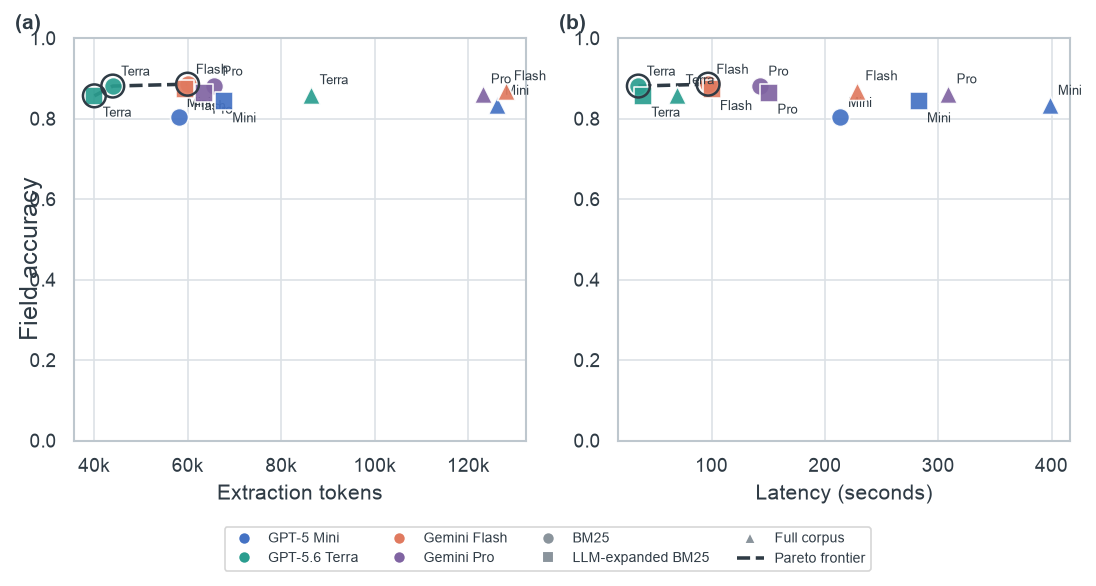

In [18]:
full_scale_figure, full_scale_axes = plot_quality_cost_pareto(
    model_retrieval,
    ylim=PARETO_FULL_YLIM,
)
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# full_scale_figure.savefig(FIGURE_DIR / "rq2-quality-cost-pareto-full-scale.png", dpi=DPI, bbox_inches="tight")
# full_scale_figure.savefig(FIGURE_DIR / "rq2-quality-cost-pareto-full-scale.pdf", bbox_inches="tight")

## RQ2 model and retrieval summaries

**How to read it.** The top row reports field accuracy by model and retrieval strategy. The bottom row reports the corresponding mean extraction-token and latency costs.

**Current observation.** Model choice changes accuracy more than retrieval choice. Retrieval changes cost more than quality: BM25 is the most efficient strategy, while full corpus has the largest cost. Terra provides the strongest overall quality-cost balance.

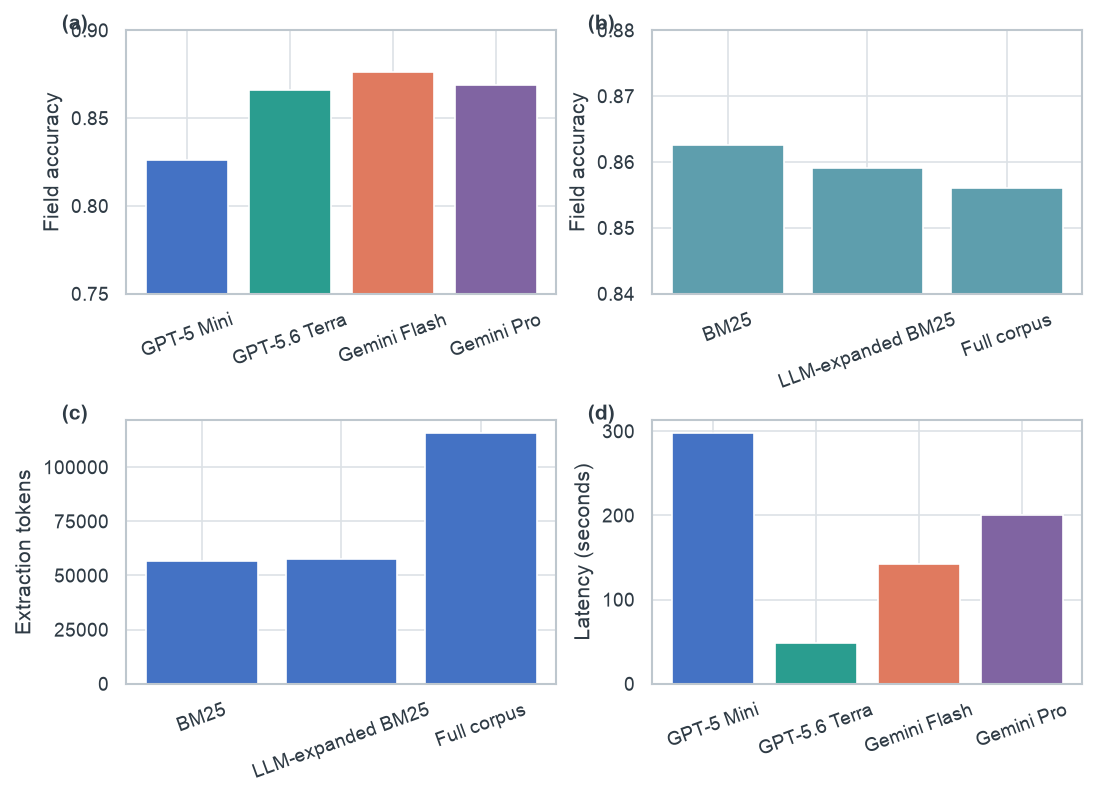

In [19]:
model_plot = model_summary.copy()
model_plot["label"] = model_plot["model"].map(MODEL_LABELS)
model_plot["color"] = model_plot["label"].map(MODEL_COLORS)
retrieval_plot = retrieval_summary.copy()
retrieval_plot["label"] = retrieval_plot["mode"].map(MODE_LABELS)

rq2_summary_figure, rq2_summary_axes = plt.subplots(
    2, 2, figsize=(7.2, 5.2), constrained_layout=True
)
rq2_summary_axes[0, 0].bar(
    model_plot["label"], model_plot["field_accuracy"], color=model_plot["color"]
)
rq2_summary_axes[0, 0].set(ylabel="Field accuracy", ylim=(0.75, 0.90))
rq2_summary_axes[0, 0].tick_params(axis="x", rotation=20)

rq2_summary_axes[0, 1].bar(
    retrieval_plot["label"], retrieval_plot["field_accuracy"], color="#5E9EAD"
)
rq2_summary_axes[0, 1].set(ylabel="Field accuracy", ylim=(0.84, 0.88))
rq2_summary_axes[0, 1].tick_params(axis="x", rotation=20)

rq2_summary_axes[1, 0].bar(
    retrieval_plot["label"], retrieval_plot["extraction_tokens"], color="#4472C4"
)
rq2_summary_axes[1, 0].set_ylabel("Extraction tokens")
rq2_summary_axes[1, 0].tick_params(axis="x", rotation=20)

rq2_summary_axes[1, 1].bar(
    model_plot["label"], model_plot["latency_sec"], color=model_plot["color"]
)
rq2_summary_axes[1, 1].set_ylabel("Latency (seconds)")
rq2_summary_axes[1, 1].tick_params(axis="x", rotation=20)

for label, axis in zip(("a", "b", "c", "d"), rq2_summary_axes.flat, strict=True):
    axis.text(
        -0.15, 1.06, f"({label})", transform=axis.transAxes,
        fontsize=10, fontweight="bold", va="top",
    )
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# rq2_summary_figure.savefig(FIGURE_DIR / "rq2-model-retrieval-summary.png", dpi=DPI, bbox_inches="tight")
# rq2_summary_figure.savefig(FIGURE_DIR / "rq2-model-retrieval-summary.pdf", bbox_inches="tight")

## RQ2 expanded-retrieval variance

**How to read it.** Each point is the mean field accuracy across the three LLM-expanded BM25 repetitions for one site-model pair; the error bar is one standard deviation.

**Current observation.** Variance is not uniform. GPT-5 Mini on ND CRC has the largest standard deviation, while several Stampede3 and Anvil model combinations are stable. Expanded retrieval therefore introduces run-to-run variation mainly in particular site-model combinations.

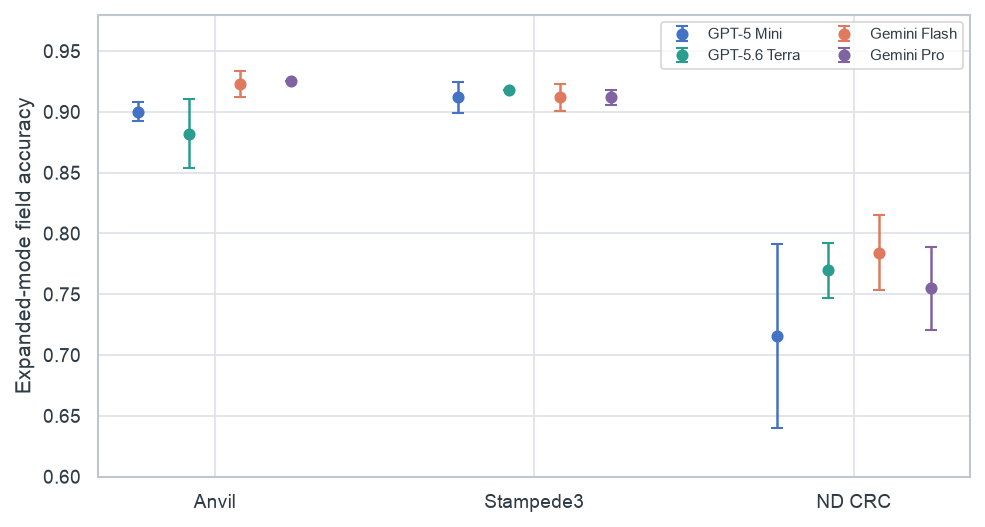

In [20]:
variance_frame = expanded_variance.copy()
variance_frame["site_label"] = variance_frame["site"].map(SITE_LABELS)
variance_frame["model_label"] = variance_frame["model"].map(MODEL_LABELS)
variance_figure, variance_axis = plt.subplots(figsize=(7.5, 4.0))
site_positions = {site: index for index, site in enumerate(SITE_LABELS.values())}
model_offsets = np.linspace(-0.24, 0.24, len(MODEL_LABELS))
for model_index, model in enumerate(MODEL_LABELS.values()):
    subset = variance_frame[variance_frame["model_label"] == model]
    x_values = [site_positions[site] + model_offsets[model_index] for site in subset["site_label"]]
    variance_axis.errorbar(
        x_values,
        subset["accuracy_mean"],
        yerr=subset["accuracy_sd"],
        fmt="o",
        capsize=3,
        color=MODEL_COLORS[model],
        label=model,
    )
variance_axis.set_xticks(range(len(SITE_LABELS)), list(SITE_LABELS.values()))
variance_axis.set(ylabel="Expanded-mode field accuracy", ylim=(0.60, 0.98))
variance_axis.legend(ncol=2, fontsize=7)
plt.show()

# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# variance_figure.savefig(FIGURE_DIR / "expanded-retrieval-variance.png", dpi=DPI, bbox_inches="tight")
# variance_figure.savefig(FIGURE_DIR / "expanded-retrieval-variance.pdf", bbox_inches="tight")

## IEEE-style LaTeX tables

The helper wraps a pandas table in a compact IEEE-style `table` environment. It uses `booktabs`; include `\usepackage{booktabs}` in the paper preamble. Every LaTeX print and file-write line below is commented out.

In [21]:
def ieee_latex_table(
    frame,
    *,
    caption,
    label,
    column_format=None,
    float_format="%.3f",
    font_size="footnotesize",
    tabcolsep="4pt",
):
    """Return a compact IEEE-compatible LaTeX table string."""
    if column_format is None:
        column_format = "l" + "r" * (len(frame.columns) - 1)
    tabular = frame.to_latex(
        index=False,
        escape=True,
        column_format=column_format,
        float_format=float_format,
    ).strip()
    return "\n".join([
        r"\begin{table}[t]",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        r"\centering",
        f"\\{font_size}",
        f"\\setlength{{\\tabcolsep}}{{{tabcolsep}}}",
        tabular,
        r"\end{table}",
    ])

### RQ1 evidence-class table

**How to read it.** Each row separates a site's identity, configuration, policy, or capability fields. This table supplies exact values behind the evidence-class chart.

**Current observation.** Measurement-backed identity and configuration are strongest. Documentation-backed policy remains above 0.80 at every site, while pilot-backed capability ranges from 0.583 at ND CRC to 0.908 at Stampede3.

In [22]:
evidence_table = evidence_metrics[[
    "site", "evidence_class", "field_accuracy", "precision", "recall"
]].copy()
evidence_table["site"] = evidence_table["site"].map(SITE_LABELS)
evidence_table = evidence_table.rename(columns={
    "site": "Site",
    "evidence_class": "Evidence class",
    "field_accuracy": "Field accuracy",
    "precision": "Precision",
    "recall": "Recall",
})
display(evidence_table.style.format(precision=3))

# evidence_latex = ieee_latex_table(
#     evidence_table,
#     caption="Profile quality by site and evidence class.",
#     label="tab:rq1-evidence-class",
# )
# print(evidence_latex)
# TABLE_DIR.mkdir(parents=True, exist_ok=True)
# (TABLE_DIR / "rq1-evidence-class.tex").write_text(evidence_latex, encoding="utf-8")

,Site,Evidence class,Field accuracy,Precision,Recall
0,Anvil,configuration,0.954,0.996,0.939
1,Anvil,policy,0.821,0.938,0.801
2,Anvil,capability,0.800,0.994,0.765
3,Anvil,identity,1.000,1.000,1.000
4,Stampede3,configuration,0.944,0.942,0.925
5,Stampede3,policy,0.876,0.959,0.892
6,Stampede3,capability,0.908,1.000,0.892
7,Stampede3,identity,1.000,1.000,1.000
8,ND CRC,configuration,0.818,1.000,0.806
9,ND CRC,policy,0.809,0.971,0.796


### RQ1 citation and conflict tables

**How to read them.** Citation integrity reports accepted documentary support and mechanical validity. Conflict counts report disagreements retained by reconciliation instead of silently choosing a source.

**Current observation.** All accepted citations are mechanically valid. Walltime-policy conflict is systematic at the two Slurm sites, which confirms that scheduler configuration and documented policy can disagree.

In [23]:
citation_table = citation_summary.copy()
citation_table["site"] = citation_table["site"].map(SITE_LABELS)
citation_table = citation_table.rename(columns={
    "site": "Site",
    "accepted_findings": "Accepted findings",
    "citations": "Citations",
    "mechanical_citation_validity": "Mechanical validity",
})[["Site", "Accepted findings", "Citations", "Mechanical validity"]]
display(citation_table.style.format({"Mechanical validity": "{:.3f}"}))

conflict_table = conflict_summary.copy()
conflict_table["site"] = conflict_table["site"].map(SITE_LABELS)
conflict_table = conflict_table.rename(columns={
    "site": "Site",
    "conflict_category": "Conflict class",
    "conflicts_per_configuration": "Conflicts/configuration",
})[["Site", "Conflict class", "Conflicts/configuration"]]
display(conflict_table.style.format({"Conflicts/configuration": "{:.3f}"}))

# citation_latex = ieee_latex_table(
#     citation_table, caption="Citation integrity by site.",
#     label="tab:rq1-citations",
# )
# print(citation_latex)
# conflict_latex = ieee_latex_table(
#     conflict_table, caption="Explicit evidence conflicts by site.",
#     label="tab:rq1-conflicts",
# )
# print(conflict_latex)

,Site,Accepted findings,Citations,Mechanical validity
0,Anvil,713,946,1.000
1,Stampede3,1216,1560,1.000
2,ND CRC,328,546,1.000


,Site,Conflict class,Conflicts/configuration
0,Anvil,other,0.278
1,Anvil,walltime_policy,7.333
2,Stampede3,walltime_policy,6.000


### RQ1 matcher-sensitivity table

**How to read it.** The reviewed matcher accepts semantically equivalent syntax patterns and set orderings; strict exact matching does not. The difference bounds how much evaluation formatting affects the reported result.

**Current observation.** Strict matching lowers overall field accuracy from 0.878 to 0.860, with the largest difference at ND CRC. This sensitivity is reported separately rather than silently treating equivalent formatting as wrong.

In [24]:
sensitivity_table = matching_sensitivity[[
    "matcher", "site", "precision", "recall", "field_accuracy"
]].copy()
sensitivity_table["site"] = sensitivity_table["site"].map(
    lambda site: "Overall" if site == "overall" else SITE_LABELS[site]
)
sensitivity_table = sensitivity_table.rename(columns={
    "matcher": "Matcher",
    "site": "Site",
    "precision": "Precision",
    "recall": "Recall",
    "field_accuracy": "Field accuracy",
})
display(sensitivity_table.style.format(precision=3))

# sensitivity_latex = ieee_latex_table(
#     sensitivity_table,
#     caption="Sensitivity to reviewed versus strict value matching.",
#     label="tab:rq1-matcher-sensitivity",
# )
# print(sensitivity_latex)

,Matcher,Site,Precision,Recall,Field accuracy
0,reviewed,Anvil,0.977,0.867,0.889
1,reviewed,Stampede3,0.957,0.906,0.912
2,reviewed,ND CRC,0.990,0.764,0.777
3,reviewed,Overall,0.971,0.862,0.878
4,strict_exact,Anvil,0.956,0.849,0.875
5,strict_exact,Stampede3,0.951,0.900,0.907
6,strict_exact,ND CRC,0.912,0.704,0.719
7,strict_exact,Overall,0.946,0.840,0.860


### RQ1 site metrics table

**How to read it.** This is the compact numerical counterpart to the site-metrics figure and is likely the strongest RQ1 table for the paper.

**Current observation.** Precision is at least 0.957 at all sites, while field accuracy ranges from 0.777 to 0.912. The precision-recall gap supports the interpretation that unresolved fields are more common than incorrect populated values.

In [25]:
site_table = site_metrics[[
    "site", "precision", "recall", "abstention_accuracy", "field_accuracy"
]].copy()
site_table["site"] = site_table["site"].map(SITE_LABELS)
site_table = site_table.rename(columns={
    "site": "Site",
    "precision": "Precision",
    "recall": "Recall",
    "abstention_accuracy": "Abstention accuracy",
    "field_accuracy": "Field accuracy",
})
display(site_table.style.format(precision=3))

# site_latex = ieee_latex_table(
#     site_table,
#     caption="Site-profile construction accuracy over 60 profile builds.",
#     label="tab:rq1-site-accuracy",
# )
# print(site_latex)
# TABLE_DIR.mkdir(parents=True, exist_ok=True)
# (TABLE_DIR / "rq1-site-accuracy.tex").write_text(site_latex, encoding="utf-8")

,Site,Precision,Recall,Abstention accuracy,Field accuracy
0,Anvil,0.977,0.867,0.969,0.889
1,Stampede3,0.957,0.906,0.935,0.912
2,ND CRC,0.990,0.764,0.972,0.777


### RQ2 model table

**How to read it.** Quality and cost are balanced over sites and retrieval strategies. Tokens are extraction tokens; latency is profile-build latency with the frozen corpus.

**Current observation.** Gemini Flash has the highest aggregate field accuracy. Terra is within roughly one percentage point while using fewer tokens and much less time.

In [26]:
model_table = model_summary[[
    "model", "field_accuracy", "extraction_tokens", "latency_sec"
]].copy()
model_table["model"] = model_table["model"].map(MODEL_LABELS)
model_table = model_table.rename(columns={
    "model": "Model",
    "field_accuracy": "Field accuracy",
    "extraction_tokens": "Tokens",
    "latency_sec": "Latency (s)",
})
display(model_table.style.format({
    "Field accuracy": "{:.3f}",
    "Tokens": "{:,.0f}",
    "Latency (s)": "{:.1f}",
}))

# model_latex = ieee_latex_table(
#     model_table,
#     caption="Profile quality and extraction cost by model.",
#     label="tab:rq2-model-cost",
# )
# print(model_latex)
# TABLE_DIR.mkdir(parents=True, exist_ok=True)
# (TABLE_DIR / "rq2-model-cost.tex").write_text(model_latex, encoding="utf-8")

,Model,Field accuracy,Tokens,Latency (s)
0,GPT-5 Mini,0.826,"83,951",298.1
1,GPT-5.6 Terra,0.866,"56,793",48.2
2,Gemini Flash,0.876,"82,454",141.8
3,Gemini Pro,0.869,"84,059",200.9


### RQ2 retrieval table

**How to read it.** Quality and cost are balanced over sites and models. Expanded mode's three repetitions together have the same weight as one BM25 or full-corpus run.

**Current observation.** Field accuracy differs by less than one percentage point across retrieval strategies. Full corpus uses about twice the tokens and latency of BM25 without improving aggregate accuracy.

In [27]:
retrieval_table = retrieval_summary[[
    "mode", "field_accuracy", "extraction_tokens", "latency_sec", "model_calls"
]].copy()
retrieval_table["mode"] = retrieval_table["mode"].map(MODE_LABELS)
retrieval_table = retrieval_table.rename(columns={
    "mode": "Retrieval",
    "field_accuracy": "Field accuracy",
    "extraction_tokens": "Tokens",
    "latency_sec": "Latency (s)",
    "model_calls": "Model calls",
})
display(retrieval_table.style.format({
    "Field accuracy": "{:.3f}",
    "Tokens": "{:,.0f}",
    "Latency (s)": "{:.1f}",
    "Model calls": "{:.1f}",
}))

# retrieval_latex = ieee_latex_table(
#     retrieval_table,
#     caption="Profile quality and extraction cost by retrieval strategy.",
#     label="tab:rq2-retrieval-cost",
# )
# print(retrieval_latex)
# TABLE_DIR.mkdir(parents=True, exist_ok=True)
# (TABLE_DIR / "rq2-retrieval-cost.tex").write_text(retrieval_latex, encoding="utf-8")

,Retrieval,Field accuracy,Tokens,Latency (s),Model calls
0,BM25,0.863,"56,900",122.1,4.7
1,LLM-expanded BM25,0.859,"57,678",143.3,5.9
2,Full corpus,0.856,"115,864",251.4,13.8


### RQ2 expanded-mode variance table

**How to read it.** Each row summarizes three expanded-mode repetitions for one site-model pair. Standard deviations quantify run-to-run variation in quality, tokens, and latency.

**Current observation.** Variance is concentrated rather than universal. GPT-5 Mini on ND CRC has the largest accuracy deviation, while several Terra and Gemini combinations are stable.

In [28]:
variance_table = expanded_variance[[
    "site", "model", "accuracy_mean", "accuracy_sd",
    "tokens_mean", "tokens_sd", "latency_mean", "latency_sd",
]].copy()
variance_table["site"] = variance_table["site"].map(SITE_LABELS)
variance_table["model"] = variance_table["model"].map(MODEL_LABELS)
variance_table = variance_table.rename(columns={
    "site": "Site",
    "model": "Model",
    "accuracy_mean": "Accuracy mean",
    "accuracy_sd": "Accuracy SD",
    "tokens_mean": "Tokens mean",
    "tokens_sd": "Tokens SD",
    "latency_mean": "Latency mean",
    "latency_sd": "Latency SD",
})
display(variance_table.style.format(precision=3))

# variance_latex = ieee_latex_table(
#     variance_table,
#     caption="Run-to-run variance for LLM-expanded BM25.",
#     label="tab:rq2-expanded-variance",
#     font_size="scriptsize",
#     tabcolsep="2.5pt",
# )
# print(variance_latex)
# TABLE_DIR.mkdir(parents=True, exist_ok=True)
# (TABLE_DIR / "rq2-expanded-variance.tex").write_text(variance_latex, encoding="utf-8")

,Site,Model,Accuracy mean,Accuracy SD,Tokens mean,Tokens SD,Latency mean,Latency SD
0,Anvil,Gemini Pro,0.925,0.000,53172.333,7228.641,141.511,20.711
1,Anvil,Gemini Flash,0.923,0.010,42794.667,9191.143,83.960,16.934
2,Anvil,GPT-5 Mini,0.900,0.008,64959.333,2560.463,316.412,30.939
3,Anvil,GPT-5.6 Terra,0.882,0.028,32433.667,2711.755,40.340,5.307
4,ND CRC,Gemini Pro,0.755,0.034,48281.333,2586.019,162.346,18.175
5,ND CRC,Gemini Flash,0.784,0.031,54233.667,2575.006,108.184,9.044
6,ND CRC,GPT-5 Mini,0.716,0.075,49662.333,13063.502,252.203,92.701
7,ND CRC,GPT-5.6 Terra,0.770,0.022,32440.667,189.115,39.832,0.978
8,Stampede3,Gemini Pro,0.912,0.006,88998.000,1093.297,148.732,7.783
9,Stampede3,Gemini Flash,0.912,0.011,81346.667,15396.527,108.132,28.230
